# Sprint 3 - US28 to US31

Regression Analysis for Transparency Assessment

## US28

**To be developed**

In [1]:
# Your solution here

## US29

**To be developed**

In [2]:
# Your solution here

## US30

Neste exercício foi aplicada uma regressão linear para estudar a relação entre o rendimento total declarado (salário e rendimentos adicionais) e o património total declarado pelos agentes políticos. Com base nas declarações mais recentes de cada agente, foram calculados os resíduos do modelo, correspondentes à diferença entre os valores observados e os valores previstos pela regressão. Posteriormente, foi analisada a distribuição dos resíduos nos dados originais e após a normalização das variáveis.


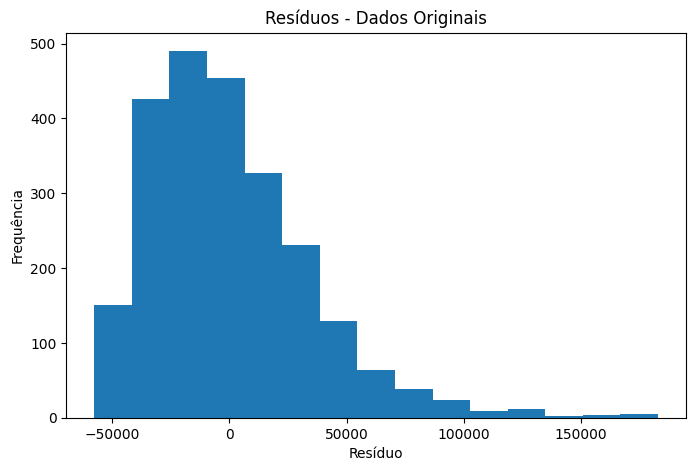

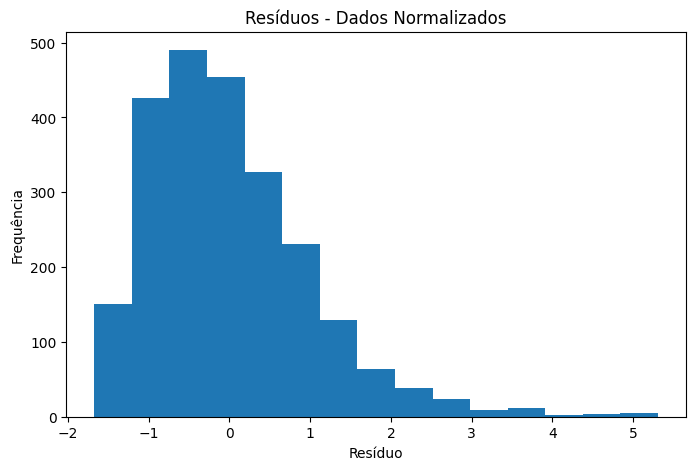

Média dos resíduos (dados originais): 4.038094919546808e-12
Média dos resíduos (dados normalizados): -3.757099914129125e-19


In [8]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Carregar o dataset
df = pd.read_csv("../Dados/dataset1_declarations.csv")

# Converter a coluna da data para formato datetime
df["declaration_date"] = pd.to_datetime(df["declaration_date"])

# Converter colunas para formato numérico
numeric_cols = [
    "gross_salary",
    "side_income_consulting",
    "side_income_board_memberships",
    "assets_in_real_estate",
    "assets_in_vehicles",
    "assets_in_stocks"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remover linhas com valores em falta
df = df.dropna(subset=numeric_cols + ["declaration_date", "agent_id"])

# Ordenar por agente e data
df = df.sort_values(["agent_id", "declaration_date"])

# Selecionar apenas a declaração mais recente de cada agente
recent_df = df.groupby("agent_id").tail(1).copy()

# Calcular o rendimento total
# Calcular o rendimento total
recent_df["total_income"] = (
    recent_df["gross_salary"]
    + recent_df["side_income_consulting"]
    + recent_df["side_income_board_memberships"]
)

# Calcular o património total
recent_df["total_assets"] = (
    recent_df["assets_in_real_estate"]
    + recent_df["assets_in_vehicles"]
    + recent_df["assets_in_stocks"]
)

# Definir variável independente (X) e dependente (y)
X = recent_df[["total_income"]]
y = recent_df["total_assets"]

# Criar e ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Calcular os valores previstos
predictions = model.predict(X)

# Calcular os resíduos
residuals = y - predictions

# Gráfico dos resíduos nos dados originais
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15)
plt.title("Resíduos - Dados Originais")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Normalizar os dados
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_norm = scaler_x.fit_transform(X)
y_norm = scaler_y.fit_transform(
    y.to_numpy().reshape(-1, 1)
).ravel()

# Criar novo modelo com os dados normalizados
model_norm = LinearRegression()
model_norm.fit(X_norm, y_norm)

# Calcular previsões e resíduos normalizados
pred_norm = model_norm.predict(X_norm)
residuals_norm = y_norm - pred_norm

# Gráfico dos resíduos após normalização
plt.figure(figsize=(8, 5))
plt.hist(residuals_norm, bins=15)
plt.title("Resíduos - Dados Normalizados")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Apresentar a média dos resíduos
print("Média dos resíduos (dados originais):", residuals.mean())
print("Média dos resíduos (dados normalizados):", residuals_norm.mean())

### Conclusão US30

A análise dos histogramas mostra que os resíduos se encontram centrados em torno de zero, o que é confirmado pelas médias dos resíduos, que são praticamente nulas tanto nos dados originais como nos dados normalizados. Este resultado indica que o modelo não apresenta enviesamento sistemático nas previsões.

No entanto, observa-se uma assimetria positiva na distribuição dos resíduos, com a presença de alguns valores extremos à direita. Estes casos correspondem a agentes cujo património declarado é significativamente superior ao valor esperado com base nos seus rendimentos declarados, podendo justificar uma análise mais detalhada por parte da Comissão de Ética.

A normalização dos dados não alterou significativamente o padrão dos resíduos, demonstrando que a estrutura do modelo se mantém estável após a transformação das variáveis. Apesar de a regressão linear fornecer uma aproximação razoável da relação entre rendimento e património, a existência de assimetrias e potenciais outliers sugere que outros fatores poderão influenciar a acumulação de património e que modelos mais complexos poderão ser considerados em análises futuras.

## US31

**To be developed**

In [ ]:
# Your solution here